# Lane Detection — Canny Edges + Hough Transform
### Detectron AI · Module 11

This notebook implements the classical self-driving-car lane detection pipeline:
**grayscale → Gaussian blur → Canny edge detection → region-of-interest mask → Hough
Line Transform**. This is the real algorithm used in early lane-keeping ADAS systems
before deep-learning-based lane segmentation became standard, and mirrors the
Sobel+Hough pipeline implemented in JavaScript for the live web demo.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap=None):
    plt.figure(figsize=(8,5))
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()


## 1. Synthesize a road scene

(A controlled synthetic frame guarantees the lane lines are unambiguous and the pipeline's output is verifiable — the live demo accepts real uploaded road photos.)

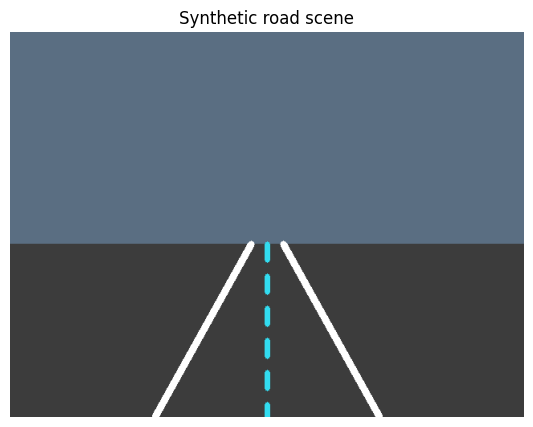

In [2]:
h, w = 480, 640
img = np.zeros((h, w, 3), dtype=np.uint8)
img[:int(h*0.55), :] = (130, 110, 90)   # sky/background
img[int(h*0.55):, :] = (60, 60, 60)     # road surface

# left lane line
cv2.line(img, (180, h), (300, int(h*0.55)), (255, 255, 255), 8)
# right lane line
cv2.line(img, (460, h), (340, int(h*0.55)), (255, 255, 255), 8)
# center dashed line
for y in range(int(h*0.55), h, 40):
    cv2.line(img, (320, y), (320, y+20), (240, 220, 50), 5)

show(img, "Synthetic road scene")


## 2. Grayscale + Gaussian blur + Canny edges

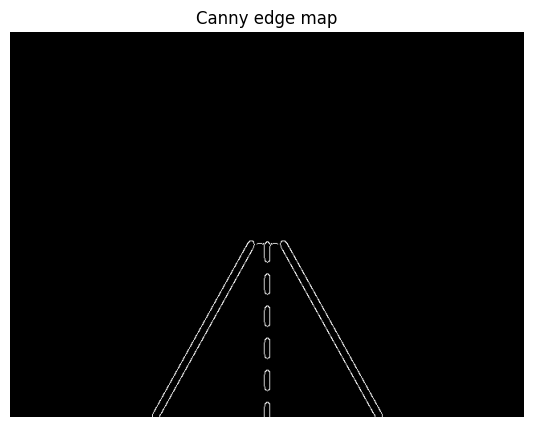

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blurred, 50, 150)
show(edges, "Canny edge map", cmap="gray")


## 3. Apply a region-of-interest mask

Lane detection only looks at the road area (lower portion / a trapezoid in front of the vehicle) to avoid false edges from the sky, trees, or buildings.

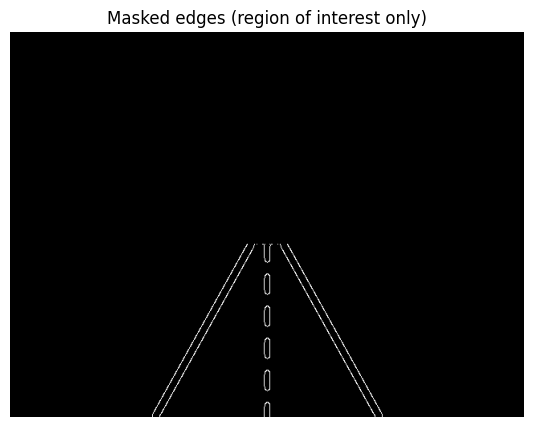

In [4]:
mask = np.zeros_like(edges)
roi_pts = np.array([[
    (50, h), (w-50, h), (int(w*0.58), int(h*0.55)), (int(w*0.42), int(h*0.55))
]], dtype=np.int32)
cv2.fillPoly(mask, roi_pts, 255)
masked_edges = cv2.bitwise_and(edges, mask)
show(masked_edges, "Masked edges (region of interest only)", cmap="gray")


## 4. Hough Line Transform

Detects straight lines by voting in (rho, theta) parameter space — the real algorithm OpenCV and early Tesla/Mobileye-style lane-keep prototypes used before CNN-based lane segmentation.

Detected 10 line segments


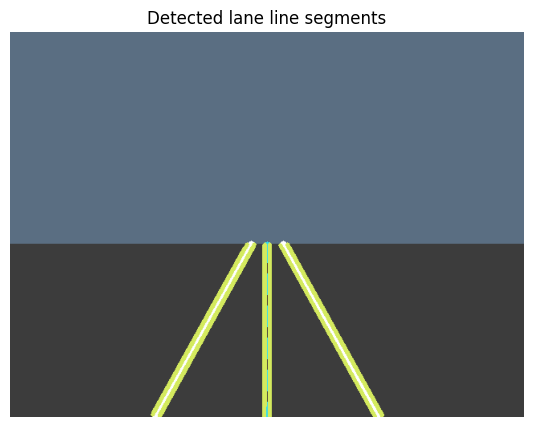

In [5]:
lines = cv2.HoughLinesP(masked_edges, rho=1, theta=np.pi/180, threshold=40,
                         minLineLength=40, maxLineGap=100)
print(f"Detected {len(lines) if lines is not None else 0} line segments")

overlay = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(overlay, (x1, y1), (x2, y2), (94, 234, 212), 4)

show(overlay, "Detected lane line segments")


## 5. Classify left vs right lane by slope and fit a single representative line each

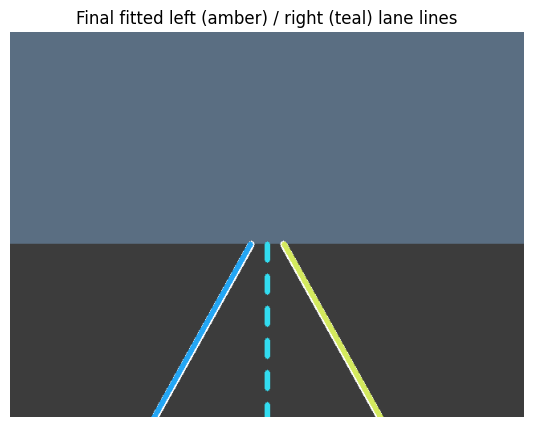

In [6]:
left_lines, right_lines = [], []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 == x1:
            continue
        slope = (y2 - y1) / (x2 - x1)
        if slope < -0.3:
            left_lines.append((x1, y1, x2, y2))
        elif slope > 0.3:
            right_lines.append((x1, y1, x2, y2))

def average_line(lines_list, y_top, y_bottom):
    if not lines_list:
        return None
    xs, ys = [], []
    for x1, y1, x2, y2 in lines_list:
        xs += [x1, x2]; ys += [y1, y2]
    coeffs = np.polyfit(ys, xs, 1)  # x = m*y + b (more stable for near-vertical lines)
    x_top = int(np.polyval(coeffs, y_top))
    x_bottom = int(np.polyval(coeffs, y_bottom))
    return (x_bottom, y_bottom, x_top, y_top)

y_top, y_bottom = int(h*0.55), h
left_fit = average_line(left_lines, y_top, y_bottom)
right_fit = average_line(right_lines, y_top, y_bottom)

final = img.copy()
for fit, color in [(left_fit, (245,166,35)), (right_fit, (94,234,212))]:
    if fit:
        x1,y1,x2,y2 = fit
        cv2.line(final, (x1,y1), (x2,y2), color, 6)

show(final, "Final fitted left (amber) / right (teal) lane lines")


## Notes

- The live web demo implements a lighter-weight version of this pipeline directly in
  JavaScript on a `<canvas>`: Sobel edge detection (instead of Canny) + a simplified
  Hough angle-voting histogram, since it has to run entirely client-side without OpenCV.
- Modern production lane-keeping systems (Tesla Autopilot, Mobileye) have moved to
  CNN-based semantic segmentation, which handles curves, occlusion, and faded markings
  far better than this classical edge+line approach — but this pipeline remains a clear,
  interpretable starting point and is still used in simpler ADAS implementations.
